In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.4904351e-05)  # constant metallicity (Z=0.02)
zmet = 1


ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape

Z = 10**-4.4904351e-05
print(Z)

0.9998966092559682


Using combined (binwise + diffuse) dust attenuation.
Initializing Dust attenuation model...
Initializing DiffuseDust model...
Dust initialization complete.
Get spectrum with dust attenuation, without nebular contribution, and without dust emission.
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


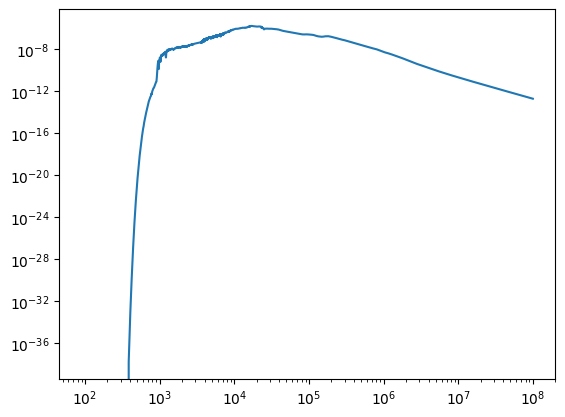

In [2]:
from sedpy_jax.observate import FilterSet as FSjax
from ceridwen.observation import Photometry

# example: one photometry observation using your FSjax filter set
fset = FSjax([
    'sdss_u0','sdss_g0','sdss_r0','sdss_i0','sdss_z0',
    'wise_w1','wise_w2',
    'jwst_f150w','jwst_f200w','jwst_f277w',
    'jwst_f356w','jwst_f444w'
])

phot_obs = Photometry(
    filters=[f.name for f in fset.filters],  # names
    flux=jnp.zeros(len(fset.filters)),       # dummy, not used in predict
    uncertainty=jnp.ones(len(fset.filters)), # dummy
    mask=jnp.ones(len(fset.filters), dtype=bool),
    name="phot_JADES"
)
# Make sure Photometry.set_filters uses FSjax internally:
phot_obs.filterset = fset

csp = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)


spec = run_spectrum_jit(csp, csp.theta_init)
plt.loglog(csp.wave, spec)


# SEDPY

In [3]:
from sedpy.smoothing import smoothspec

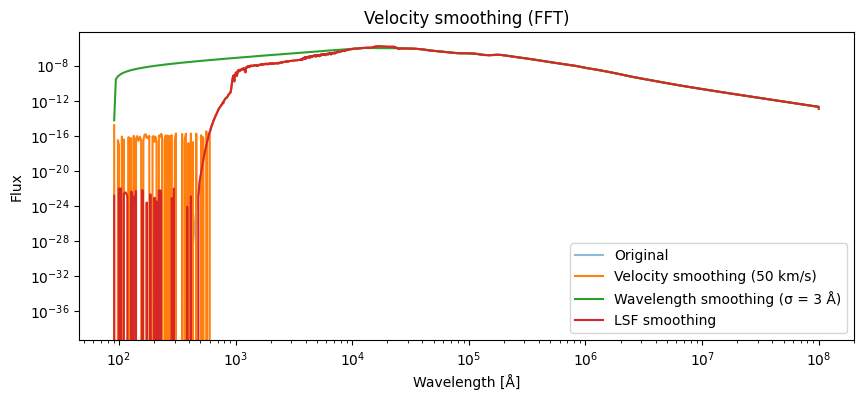

In [4]:
sigma_v = 50.0  # km/s
wave = csp.wave
spec_vel = smoothspec(
    wave=wave,
    spec=spec,
    resolution=sigma_v,
    outwave=wave,
    smoothtype="vel",
    fftsmooth=True,
)
sigma_A = 1.0  # constant sigma in Å

spec_lambda = smoothspec(
    wave=wave,
    spec=spec,
    resolution=sigma_A,
    outwave=wave,
    smoothtype="lambda",
    fftsmooth=True,
)
def simple_lsf(wave, a=3.0, b=0.0005):
    return a + b * (wave - 5500)  # Å

spec_lsf = smoothspec(
    wave=wave,
    spec=spec,
    outwave=wave,
    smoothtype="lsf",
    resolution=None,
    lsf=simple_lsf,
    fftsmooth=True,
)


plt.figure(figsize=(10,4))
plt.loglog(wave, spec, label="Original", alpha=0.5)
plt.loglog(wave, spec_vel, label="Velocity smoothing (50 km/s)")
plt.plot(wave, spec_lambda, label="Wavelength smoothing (σ = 3 Å)")

plt.plot(wave, spec_lsf, label="LSF smoothing")

plt.legend()
plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title("Velocity smoothing (FFT)")
plt.show()

In [52]:
import jax
import jax.numpy as jnp
from jax.numpy.fft import rfft, irfft, rfftfreq


@jax.jit
def smooth_fft_jax(dx, spec, sigma):
    """
    JAX-optimized FFT Gaussian convolution.

    Parameters
    ----------
    dx : float
        Grid spacing (same units as sigma).

    spec : array, shape (N,)
        Spectrum values.

    sigma : float
        Gaussian width.

    Returns
    -------
    spec_conv : array, shape (N,)
        Gaussian-smoothed spectrum.
    """
    N = spec.shape[0]

    # Fourier coordinates (cycles per unit dx)
    ss = rfftfreq(N, d=dx)

    # Optionally apply sedpy's stabilisation hack to DC mode:
    ss = ss.at[0].set(0.000001)

    # Analytic Fourier-space Gaussian
    # exp( -2 * pi^2 * sigma^2 * ss^2 )
    taper = jnp.exp(-2.0 * (jnp.pi ** 2) * (sigma ** 2) * (ss ** 2))

    # FFT of the spectrum
    spec_ff = rfft(spec)

    # Multiply in Fourier space (convolution theorem)
    ff_tapered = spec_ff * taper

    # Inverse FFT back to real space
    spec_conv = irfft(ff_tapered, n=N)

    return spec_conv

In [53]:
N = spec.shape[0]
ss = rfftfreq(N, d=dx)
ss = ss.at[0].set(0.01)
taper = jnp.exp(-2.0 * (jnp.pi ** 2) * (sigma ** 2) * (ss ** 2))

ss_np = numpy.fft.rfftfreq(len(spec), d=dx)
ss_np[0] = 0.01
taper_np = np.exp(-2 * (np.pi ** 2) * (sigma ** 2) * (ss_np ** 2))


print('ss shape', ss.shape)
print('ss_np.shape', ss_np.shape)
np.sum(taper - taper_np)

ss shape (2998,)
ss_np.shape (2998,)


Array(2.0416455e-06, dtype=float32)

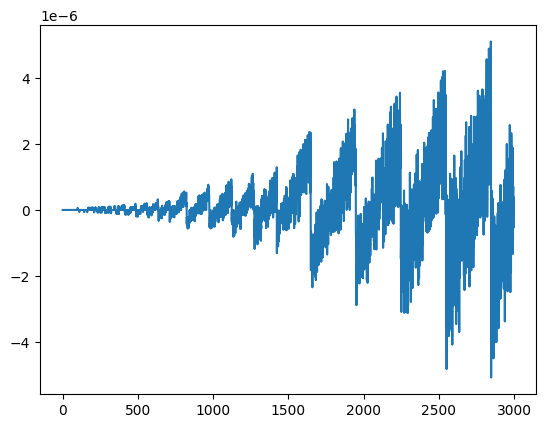

In [54]:
plt.plot((taper - taper_np)/taper_np)

ValueError: operands could not be broadcast together with shapes (5994,) (11988,) 

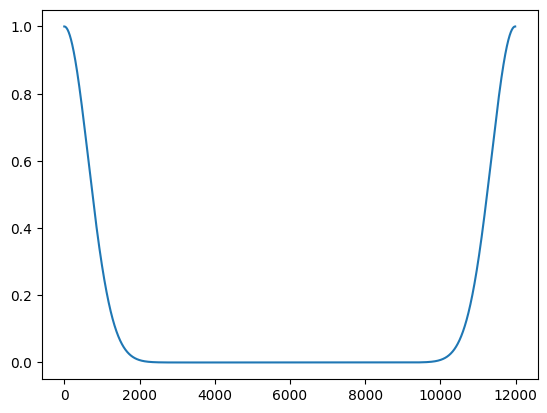

In [ ]:
from sedpy.smoothing import smooth_fft as smooth_fft_np
import numpy
def smooth_fft_old(dx, spec, sigma):
    """Basic math for FFT convolution with a gaussian kernel.

    Parameters
    ----------
    dx : ndarray of shape ``(N_pix,)``
        The wavelength or velocity spacing, same units as ``sigma``

    spec : ndarry of shape ``(N_pix,)``
        The spectrum flux vector

    sigma : float
        The width of the Gaussian kernel, same units as ``dx``

    Returns
    -------
    smoothed_spec : ndarry of shape ``(N_pix,)``
        The smoothed spectrum, on the same grid as the input.
    """
    # The Fourier coordinate
    N = len(spec)
    ss = numpy.fft.fftfreq(2 * N, d=dx)
    # Make the fourier space taper; just the analytical fft of a gaussian
    
    taper = np.exp(-2 * (np.pi ** 2) * (sigma ** 2) * (ss ** 2))
    # ss[0] = 0.01  # hack
    # plt.plot(taper)
    # Fourier transform the spectrum
    spec_ff = np.fft.fft(spec)
    # Multiply in fourier space
    ff_tapered = spec_ff * taper
    # Fourier transform back
    spec_conv = np.fft.ifft(ff_tapered).real
    print(type(spec_conv))
    return spec_conv

    #   # The Fourier coordinate
    # N = len(spec)
    # spec_pad = np.pad(spec, (N//2, N//2))
    # ss = np.fft.fftshift(np.fft.fftfreq(2*N, d=dx))
    # # Make the fourier space taper; just the analytical fft of a gaussian
    # taper = np.exp(-2 * (np.pi ** 2) * (sigma ** 2) * (ss ** 2))
    # # ss[0] = 0.01  # hack
    # # plt.plot(taper)
    # # Fourier transform the spectrum
    # spec_ff = np.fft.fft(np.fft.fftshift(spec_pad))
    # # Multiply in fourier space
    # ff_tapered = spec_ff * taper
    # # Fourier transform back
    # spec_conv = np.fft.fftshift(np.fft.ifft(ff_tapered))
    # spec_conv = spec_conv[N//2:(3*N)//2]
    # return spec_conv


#N = 4096
dx = 1.0
sigma = 3.0

spec_np = np.array(spec)
# sedpy reference
ref = smooth_fft_old(dx, np.array(spec), sigma)

# JAX output
spec_j = jnp.array(spec)
out = np.array(smooth_fft_jax(dx, spec_j, sigma))

# Normalised residuals
norm_res = (out - ref) / np.where(ref != 0, ref, 1)

# Print stats
print("Max abs diff:", np.max(np.abs(norm_res)))
print("Mean abs diff:", np.mean(np.abs(norm_res)))

# --- Plot ---
fig, ax = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# Top panel: smoothed spectra
ax[0].loglog(wave, ref, color = 'dodgerblue', label="sedpy smooth_fft", zorder = 100)
# ax[0].loglog(wave, out, "--", color = 'orange', label="JAX smooth_fft", alpha=0.7)
ax[0].loglog(wave, spec, color = 'crimson', label="Original", alpha=0.6)

ax[0].legend()
ax[0].set_ylabel("Flux")
ax[0].set_title("sedpy vs JAX FFT smoothing")

# Bottom panel: normalised residuals
ax[1].plot(wave,norm_res, color="black")
ax[1].axhline(0, color="gray", lw=1)
ax[1].set_ylabel("(out - ref) / ref")
ax[1].set_xlabel("Pixel index")
ax[1].set_yscale('symlog')

plt.tight_layout()
plt.show()

In [24]:
spec_np[0] =1